# Análisis de Viabilidad — Estimación de Humedad del Suelo
**Instituciones:** PUCP y UNALM — Lima, Perú  
**Objetivo:** Evaluar si las variables meteorológicas disponibles en cada estación permiten estimar la humedad del suelo medida por sensores NUCScout, CRN y MEDUSA.

## 0. Librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos
### 1.1 Datos combinados (UNALM + NUCScout PUCP)

In [5]:
df_total = pd.read_csv('../data/DATA_CRN_NUC_MEDUSA_TOTAL.csv')
df_total['Timestamp'] = pd.to_datetime(df_total['Timestamp'], dayfirst=True)
df_total = df_total.set_index('Timestamp').sort_index()

print(f'Registros totales: {len(df_total):,}')
print(f'Período: {df_total.index.min().date()} → {df_total.index.max().date()}')
print(f'Columnas: {list(df_total.columns)}')

Registros totales: 19,968
Período: 2023-10-15 → 2026-01-23
Columnas: ['Barometer (mb)', 'Absolute Pressure (mb)', 'Temperature (°C)', 'Humidity (%)', 'Dew Point', 'Wet Bulb', 'Average Wind Speed (m/s)', 'Heat Index', 'Solar Radiation (W/m²)', 'Solar Energy (Ly)', 'MEDUSA - Activity (Bq)', 'MEDUSA - Soil Water Content (m³/m³)', 'NUCScout - Total Count Rate', 'NUCScout - Soil Water Content (m³/m³)', 'CRN (Neutrons) - Counts', 'CRN (Neutrons) - Corrected Counts', 'CRN - Soil Water Content (m³/m³)']


### 1.2 Datos meteorológicos PUCP (archivos separados)

In [ ]:
PUCP_FILES = {
    'Air Temperature'   : '../data/Datos_meteorologicos/Temperatura_ambiente_PUCP.csv',
    'Relative Humidity' : '../data/Datos_meteorologicos/Humedad_relativa_PUCP.csv',
    'Absolute Humidity' : '../data/Datos_meteorologicos/Humedad_absoluta_PUCP.csv',
    'GHI'               : '../data/Datos_meteorologicos/GHI_PUCP.csv',
    'Wind Speed (km/h)' : '../data/Datos_meteorologicos/Velocidad_viento_PUCP.csv',
    'Air Pressure'      : '../data/Datos_meteorologicos/Presion_aire_PUCP.csv',
    'Absolute Pressure' : '../data/Datos_meteorologicos/Pression_absoluta_aire_PUCP.csv',
    'Air Density'       : '../data/Datos_meteorologicos/Densidad_aire_PUCP.csv',
    'Wind Direction'    : '../data/Datos_meteorologicos/Direccion_viento_PUCP.csv',
}

dfs_pucp = []
for varname, path in PUCP_FILES.items():
    df = pd.read_csv(path, sep=';')
    df.columns = df.columns.str.strip()
    df['DATETIME'] = pd.to_datetime(df['DATE'] + ' ' + df['TIME'], dayfirst=True)
    val_col = [c for c in df.columns if c not in ['DATE', 'TIME', 'DATETIME']][0]
    df_h = df.set_index('DATETIME')[[val_col]].resample('1h').mean()
    df_h.columns = [varname]
    dfs_pucp.append(df_h)

df_pucp_meteo = pd.concat(dfs_pucp, axis=1)

print(f'Variables PUCP cargadas: {list(df_pucp_meteo.columns)}')
print(f'Período: {df_pucp_meteo.index.min().date()} → {df_pucp_meteo.index.max().date()}')
print(f'Registros horarios: {len(df_pucp_meteo):,}')

Variables PUCP cargadas: ['Air Temperature', 'Relative Humidity', 'Absolute Humidity', 'GHI', 'Wind Speed (km/h)', 'Air Pressure', 'Absolute Pressure', 'Air Density', 'Wind Direction']
Período: 2023-10-01 → 2024-04-01
Registros horarios: 4,407


## 2. Calidad de datos
### 2.1 Porcentaje de nulos por variable

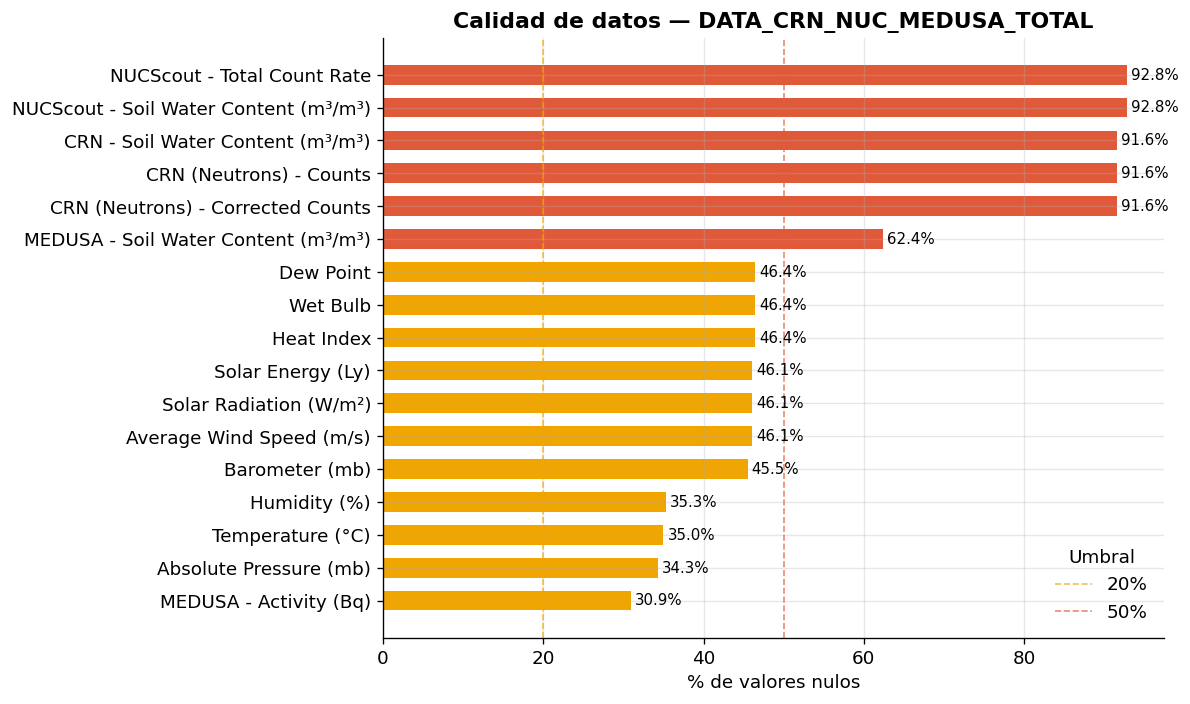

In [7]:
nulls = (df_total.isnull().mean() * 100).round(1).sort_values(ascending=True)

colors = ['#e05a3a' if v > 50 else '#f0a500' if v > 20 else '#2ecc71' for v in nulls]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(nulls.index, nulls.values, color=colors, edgecolor='none', height=0.6)
ax.axvline(20, color='#f0a500', linestyle='--', linewidth=1, alpha=0.7, label='20%')
ax.axvline(50, color='#e05a3a', linestyle='--', linewidth=1, alpha=0.7, label='50%')
for bar, val in zip(bars, nulls.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
ax.set_xlabel('% de valores nulos')
ax.set_title('Calidad de datos — DATA_CRN_NUC_MEDUSA_TOTAL', fontweight='bold')
ax.legend(title='Umbral', frameon=False)
plt.tight_layout()
plt.savefig('../figures/01_nulls_total.png', bbox_inches='tight')
plt.show()

In [8]:
nulls_pucp = (df_pucp_meteo.isnull().mean() * 100).round(2)
print('Porcentaje de nulos — Archivos PUCP (resolución horaria)')
print(nulls_pucp.to_string())

Porcentaje de nulos — Archivos PUCP (resolución horaria)
Air Temperature       8.60
Relative Humidity     8.60
Absolute Humidity     8.58
GHI                  46.45
Wind Speed (km/h)     8.55
Air Pressure          8.58
Absolute Pressure     8.58
Air Density           8.58
Wind Direction        8.55


## 3. Análisis de solapamiento temporal
### 3.1 PUCP — Meteo vs NUCScout

In [9]:
nuc = df_total[['NUCScout - Soil Water Content (m³/m³)']].dropna()
nuc.columns = ['NUCScout_SWC']

df_pucp = df_pucp_meteo.join(nuc, how='inner').dropna(subset=['NUCScout_SWC'])

print('=== Solapamiento PUCP ===')
print(f'Registros útiles (meteo + NUCScout): {len(df_pucp):,}')
print(f'Período: {df_pucp.index.min().date()} → {df_pucp.index.max().date()}')
print()
print('Estadísticas NUCScout SWC:')
print(df_pucp['NUCScout_SWC'].describe().round(4).to_string())

=== Solapamiento PUCP ===
Registros útiles (meteo + NUCScout): 1,436
Período: 2023-10-27 → 2024-02-29

Estadísticas NUCScout SWC:
count    1436.0000
mean        0.1279
std         0.0366
min         0.0331
25%         0.0862
50%         0.1464
75%         0.1549
max         0.1898


### 3.2 UNALM — Meteo vs MEDUSA y CRN

In [10]:
METEO_UNALM = ['Barometer (mb)', 'Temperature (°C)', 'Humidity (%)',
                'Solar Radiation (W/m²)', 'Average Wind Speed (m/s)']
SWC_COLS = {
    'MEDUSA': 'MEDUSA - Soil Water Content (m³/m³)',
    'CRN'   : 'CRN - Soil Water Content (m³/m³)'
}

for sensor, col in SWC_COLS.items():
    sub = df_total[[col] + METEO_UNALM].dropna()
    print(f'=== UNALM — {sensor} ===')
    print(f'Registros completos (sensor + meteo): {len(sub):,}')
    if len(sub) > 0:
        print(f'Período: {sub.index.min().date()} → {sub.index.max().date()}')
        print(f'SWC — min: {sub[col].min():.4f}, max: {sub[col].max():.4f}, std: {sub[col].std():.4f}')
    print()

=== UNALM — MEDUSA ===
Registros completos (sensor + meteo): 3,745
Período: 2024-06-08 → 2025-12-02
SWC — min: 0.0039, max: 0.1500, std: 0.0274

=== UNALM — CRN ===
Registros completos (sensor + meteo): 326
Período: 2025-11-12 → 2025-11-28
SWC — min: -0.4931, max: 1.7602, std: 0.1193



## 4. Análisis de correlaciones
### 4.1 PUCP — Variables meteorológicas vs NUCScout SWC

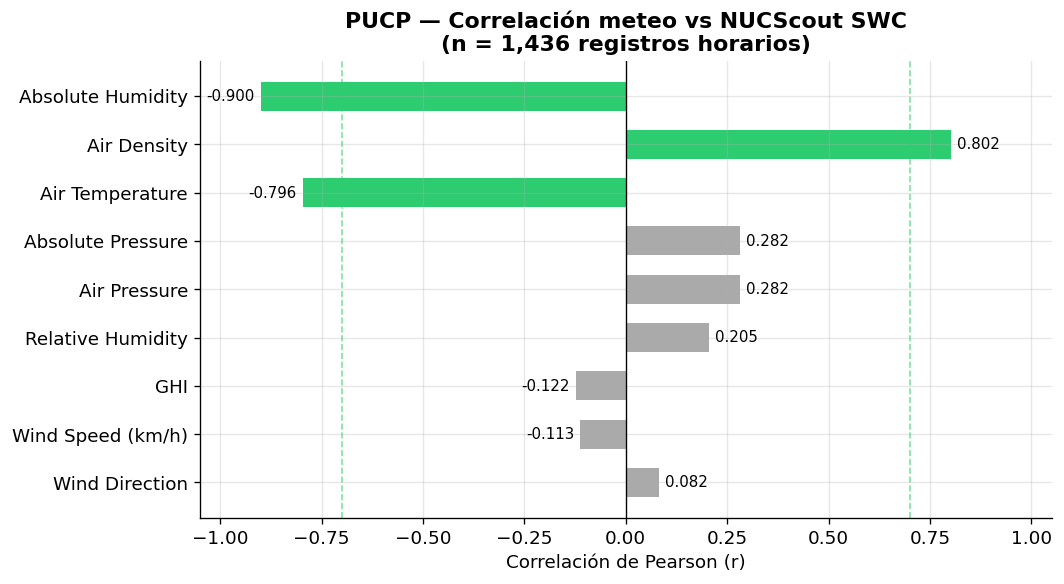

In [11]:
meteo_vars_pucp = [c for c in df_pucp.columns if c != 'NUCScout_SWC']
corrs_pucp = df_pucp[meteo_vars_pucp].corrwith(df_pucp['NUCScout_SWC']).sort_values(key=abs, ascending=True)

colors = ['#2ecc71' if abs(v) >= 0.7 else '#f0a500' if abs(v) >= 0.4 else '#aaaaaa' for v in corrs_pucp]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corrs_pucp.index, corrs_pucp.values, color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.7, color='#2ecc71', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(-0.7, color='#2ecc71', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars, corrs_pucp.values):
    x_pos = bar.get_width() + (0.015 if val >= 0 else -0.015)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=9)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel('Correlación de Pearson (r)')
ax.set_title('PUCP — Correlación meteo vs NUCScout SWC\n(n = 1,436 registros horarios)', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/02_corr_pucp.png', bbox_inches='tight')
plt.show()

### 4.2 UNALM — Variables meteorológicas vs MEDUSA y CRN

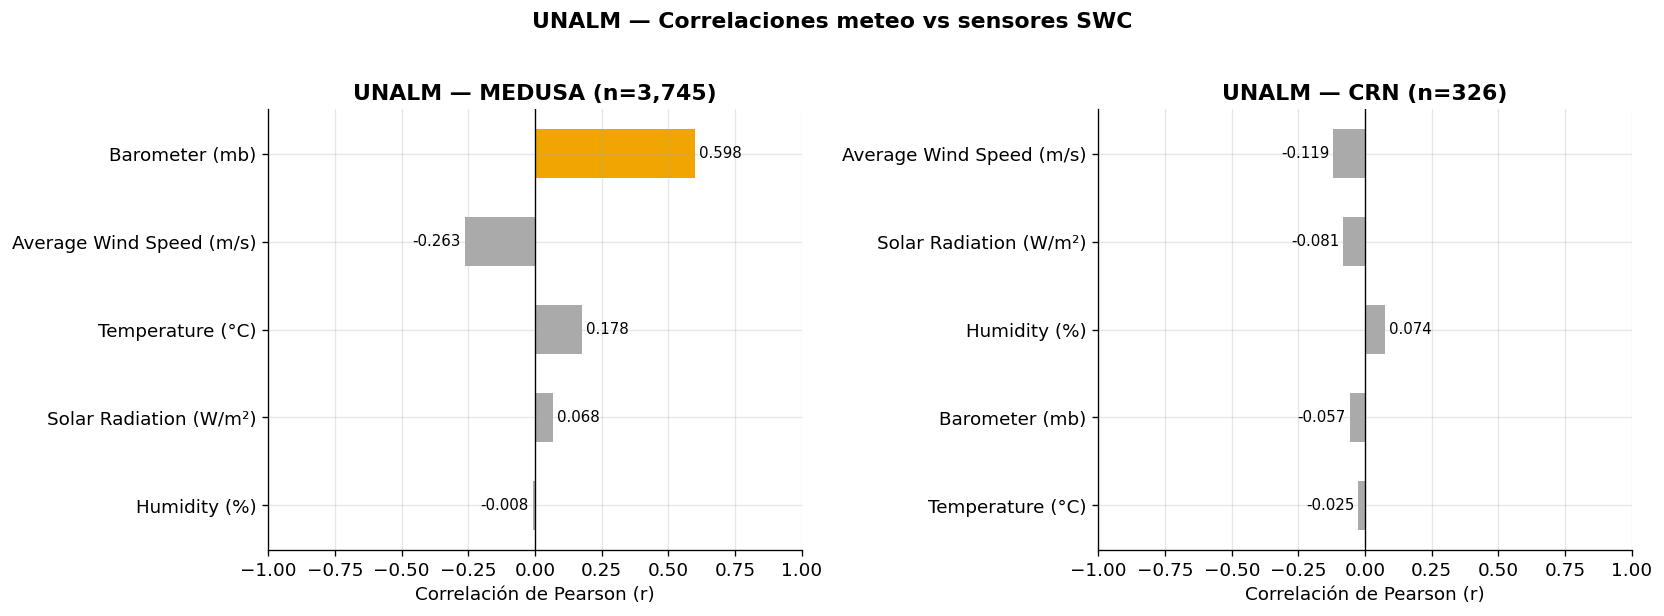

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sensor, col) in zip(axes, SWC_COLS.items()):
    sub = df_total[[col] + METEO_UNALM].dropna()
    if len(sub) < 10:
        ax.text(0.5, 0.5, f'Datos insuficientes\n(n={len(sub)})',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'UNALM — {sensor}', fontweight='bold')
        continue
    corrs = sub[METEO_UNALM].corrwith(sub[col]).sort_values(key=abs, ascending=True)
    colors = ['#2ecc71' if abs(v) >= 0.7 else '#f0a500' if abs(v) >= 0.4 else '#aaaaaa' for v in corrs]
    bars = ax.barh(corrs.index, corrs.values, color=colors, edgecolor='none', height=0.55)
    ax.axvline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, corrs.values):
        x_pos = bar.get_width() + (0.015 if val >= 0 else -0.015)
        ha = 'left' if val >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=9)
    ax.set_xlim(-1.0, 1.0)
    ax.set_xlabel('Correlación de Pearson (r)')
    ax.set_title(f'UNALM — {sensor} (n={len(sub):,})', fontweight='bold')

plt.suptitle('UNALM — Correlaciones meteo vs sensores SWC', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/03_corr_unalm.png', bbox_inches='tight')
plt.show()

## 5. Series temporales — Comportamiento de la humedad del suelo

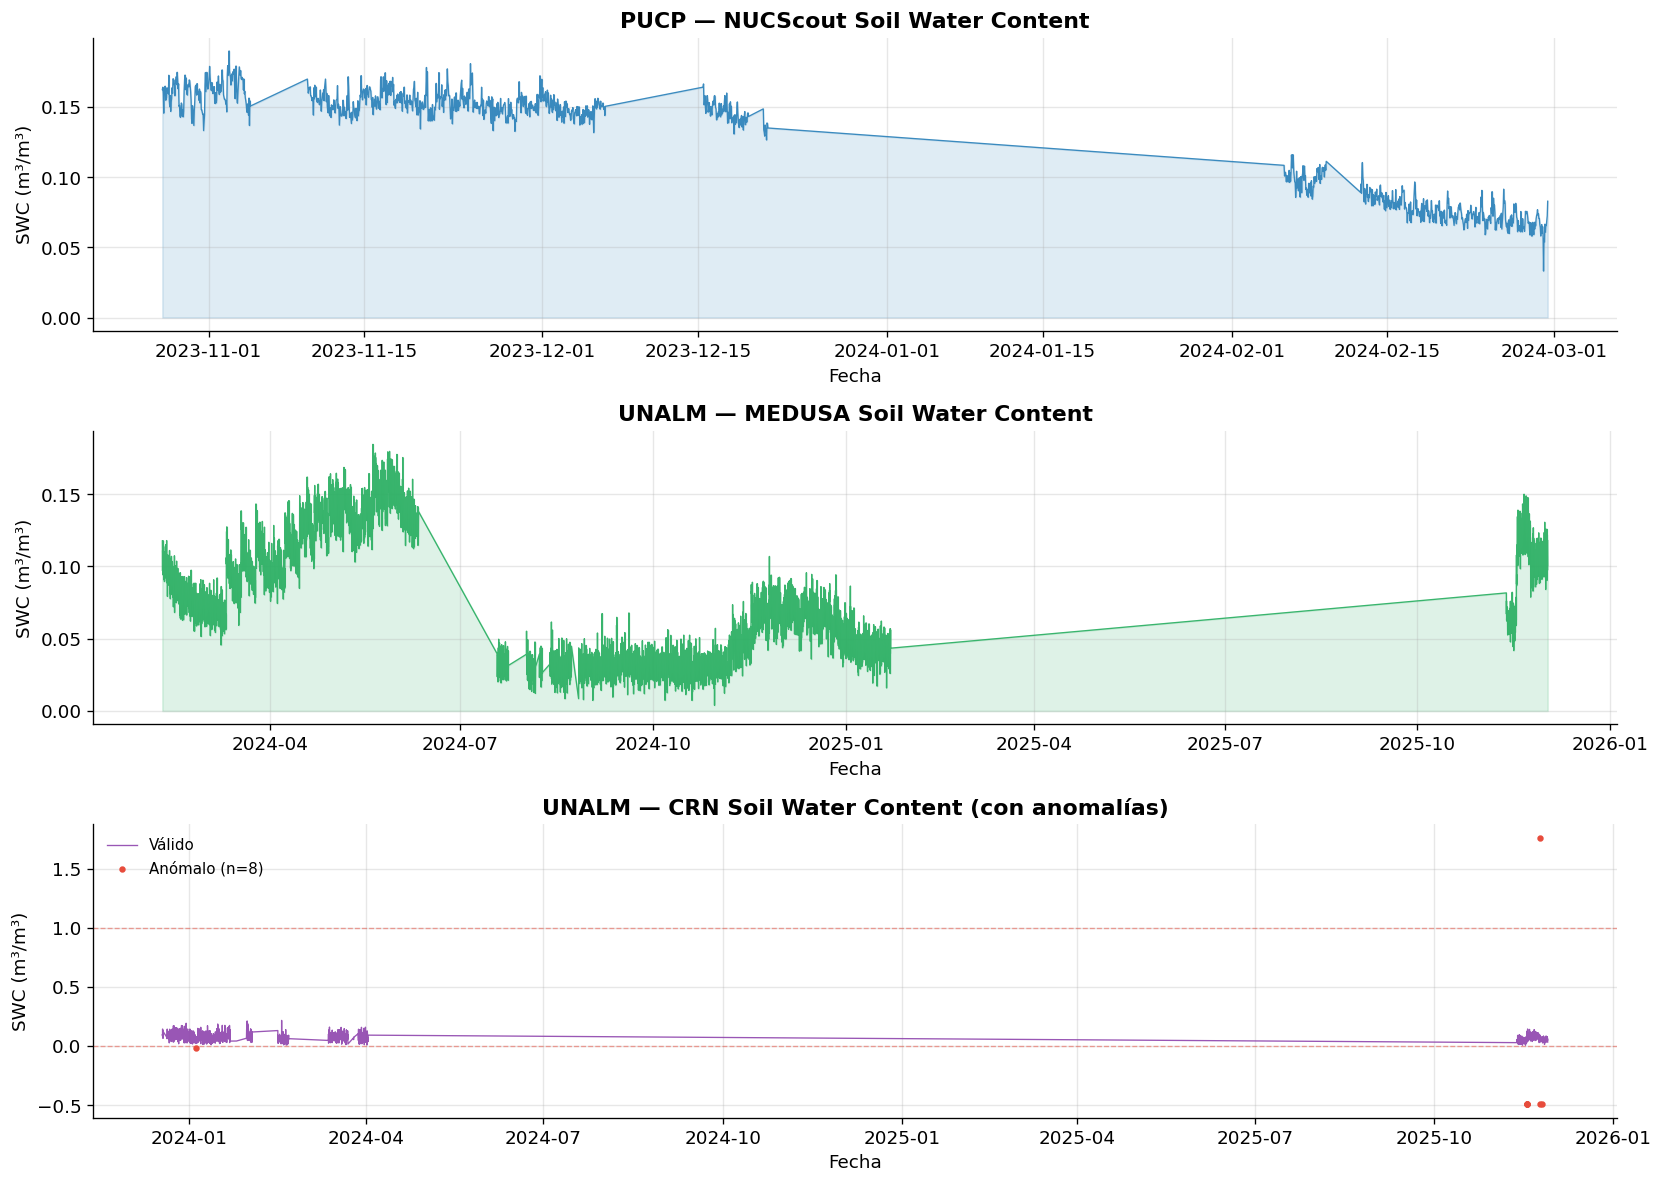

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# NUCScout PUCP
axes[0].plot(df_pucp.index, df_pucp['NUCScout_SWC'], color='#2980b9', linewidth=0.8, alpha=0.9)
axes[0].set_ylabel('SWC (m³/m³)')
axes[0].set_title('PUCP — NUCScout Soil Water Content', fontweight='bold')
axes[0].fill_between(df_pucp.index, df_pucp['NUCScout_SWC'], alpha=0.15, color='#2980b9')

# MEDUSA UNALM
medusa = df_total['MEDUSA - Soil Water Content (m³/m³)'].dropna()
axes[1].plot(medusa.index, medusa.values, color='#27ae60', linewidth=0.8, alpha=0.9)
axes[1].set_ylabel('SWC (m³/m³)')
axes[1].set_title('UNALM — MEDUSA Soil Water Content', fontweight='bold')
axes[1].fill_between(medusa.index, medusa.values, alpha=0.15, color='#27ae60')

# CRN UNALM (con límites físicos)
crn = df_total['CRN - Soil Water Content (m³/m³)'].dropna()
crn_clean = crn[(crn >= 0) & (crn <= 1)]
crn_anom  = crn[(crn < 0) | (crn > 1)]
axes[2].plot(crn_clean.index, crn_clean.values, color='#8e44ad', linewidth=0.8, alpha=0.9, label='Válido')
axes[2].scatter(crn_anom.index, crn_anom.values, color='#e74c3c', s=8, zorder=5, label=f'Anómalo (n={len(crn_anom)})')
axes[2].axhline(0, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].axhline(1, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].set_ylabel('SWC (m³/m³)')
axes[2].set_title('UNALM — CRN Soil Water Content (con anomalías)', fontweight='bold')
axes[2].legend(frameon=False, fontsize=9)

for ax in axes:
    ax.set_xlabel('Fecha')

plt.tight_layout()
plt.savefig('../figures/04_timeseries_swc.png', bbox_inches='tight')
plt.show()

## 6. Scatter plots — Predictores más fuertes vs SWC
### 6.1 PUCP

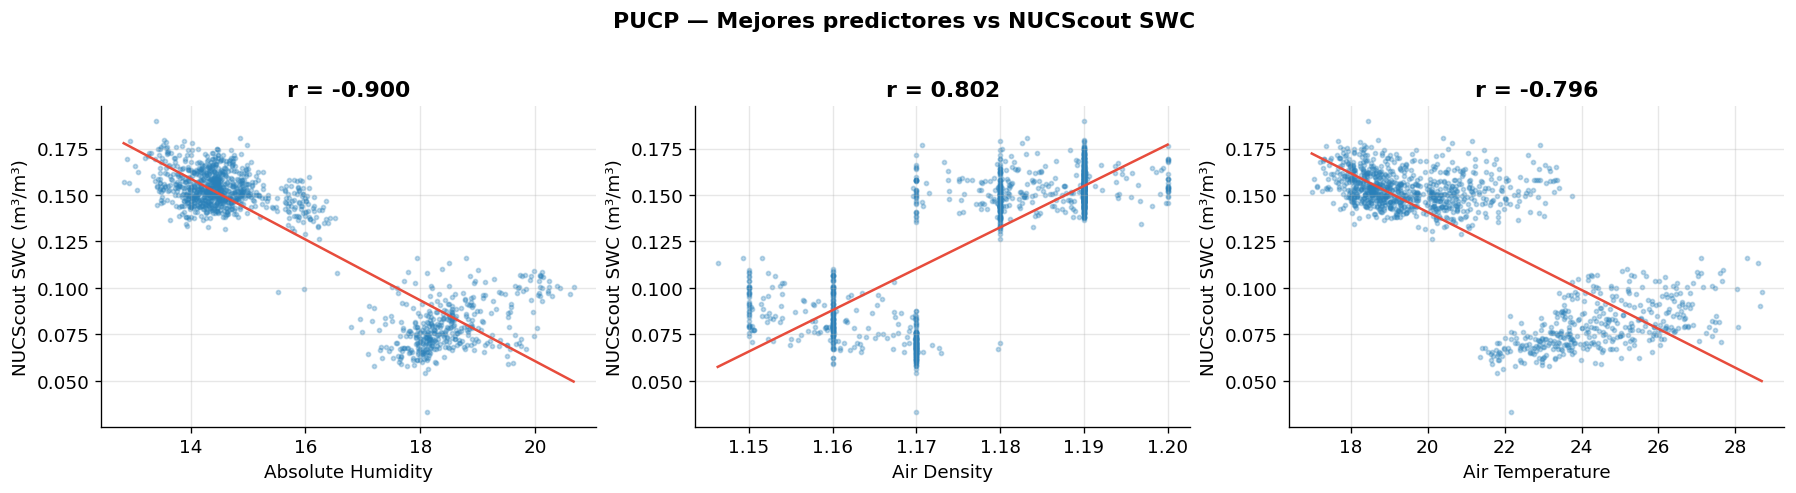

In [14]:
top_predictors_pucp = ['Absolute Humidity', 'Air Density', 'Air Temperature']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes, top_predictors_pucp):
    sub = df_pucp[[var, 'NUCScout_SWC']].dropna()
    r = sub.corr().iloc[0, 1]
    ax.scatter(sub[var], sub['NUCScout_SWC'], alpha=0.3, s=6, color='#2980b9')
    m, b = np.polyfit(sub[var], sub['NUCScout_SWC'], 1)
    x_line = np.linspace(sub[var].min(), sub[var].max(), 100)
    ax.plot(x_line, m*x_line + b, color='#e74c3c', linewidth=1.5)
    ax.set_xlabel(var)
    ax.set_ylabel('NUCScout SWC (m³/m³)')
    ax.set_title(f'r = {r:.3f}', fontweight='bold')

plt.suptitle('PUCP — Mejores predictores vs NUCScout SWC', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/05_scatter_pucp.png', bbox_inches='tight')
plt.show()

### 6.2 UNALM — MEDUSA

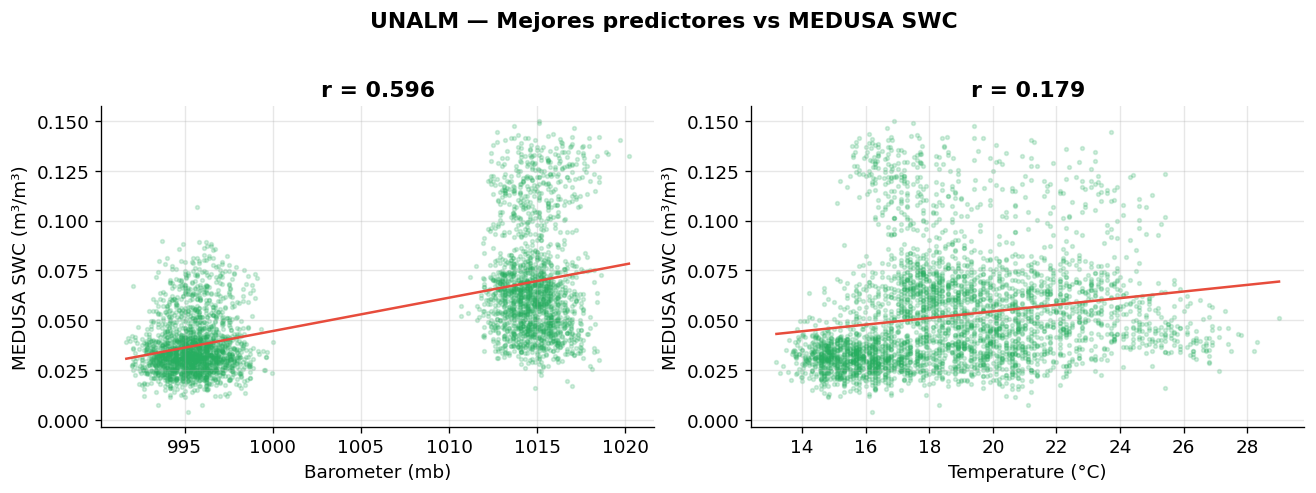

In [15]:
top_predictors_unalm = ['Barometer (mb)', 'Temperature (°C)']
df_medusa = df_total[['MEDUSA - Soil Water Content (m³/m³)'] + top_predictors_unalm].dropna()
df_medusa.columns = ['MEDUSA_SWC'] + top_predictors_unalm

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, var in zip(axes, top_predictors_unalm):
    sub = df_medusa[[var, 'MEDUSA_SWC']].dropna()
    r = sub.corr().iloc[0, 1]
    ax.scatter(sub[var], sub['MEDUSA_SWC'], alpha=0.2, s=5, color='#27ae60')
    m, b = np.polyfit(sub[var], sub['MEDUSA_SWC'], 1)
    x_line = np.linspace(sub[var].min(), sub[var].max(), 100)
    ax.plot(x_line, m*x_line + b, color='#e74c3c', linewidth=1.5)
    ax.set_xlabel(var)
    ax.set_ylabel('MEDUSA SWC (m³/m³)')
    ax.set_title(f'r = {r:.3f}', fontweight='bold')

plt.suptitle('UNALM — Mejores predictores vs MEDUSA SWC', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/06_scatter_unalm.png', bbox_inches='tight')
plt.show()

## 7. Matriz de correlación — PUCP completo

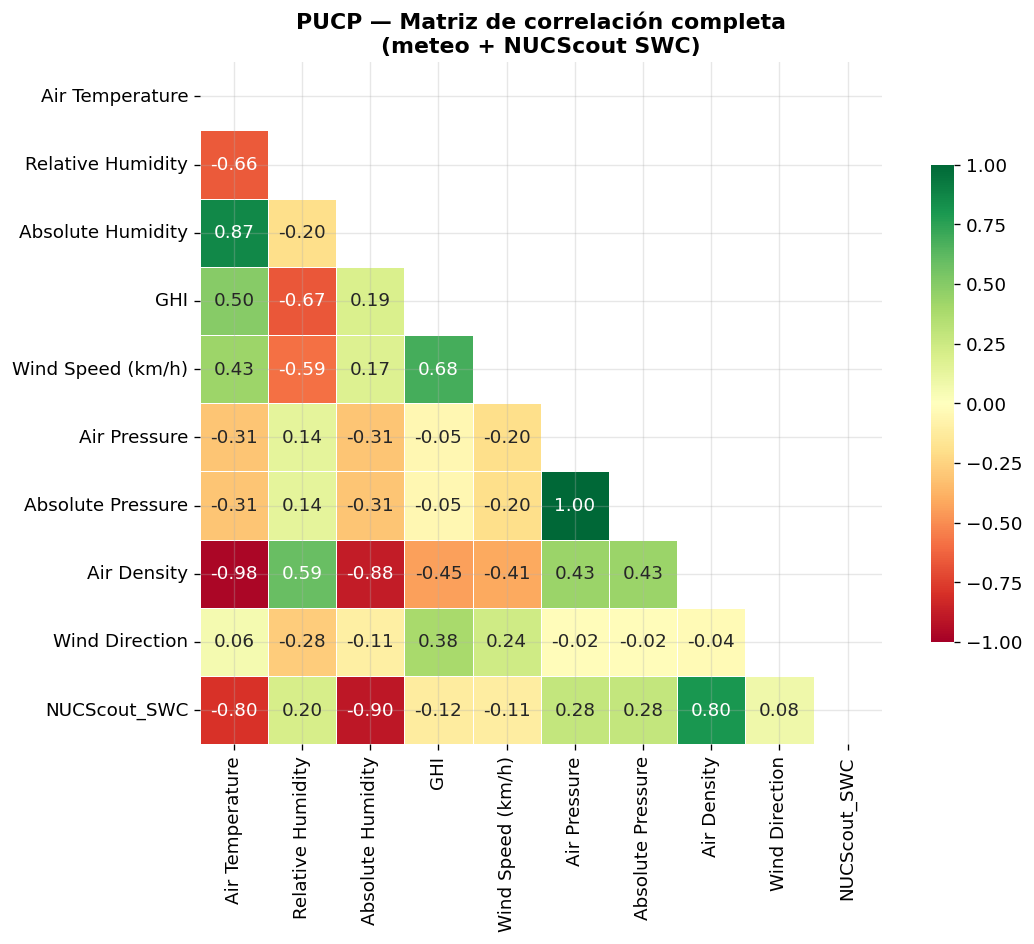

In [16]:
corr_matrix = df_pucp.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('PUCP — Matriz de correlación completa\n(meteo + NUCScout SWC)', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/07_corr_matrix_pucp.png', bbox_inches='tight')
plt.show()

## 8. Resumen de viabilidad

In [18]:
summary = pd.DataFrame({
    'Institución'       : ['PUCP', 'UNALM', 'UNALM'],
    'Sensor objetivo'   : ['NUCScout', 'MEDUSA', 'CRN'],
    'Registros útiles'  : [1436, len(df_medusa), 329],
    'Mejor predictor'   : ['Humedad absoluta', 'Barómetro', 'Vel. viento'],
    'Correlación máx'   : [-0.900, 0.573, -0.120],
    'Calidad meteo'     : ['Excelente', 'Parcial', 'Parcial'],
    'Viabilidad'        : ['Alta', 'Media', 'No recomendado']
})

def color_viab(val):
    colors = {'Alta': 'background-color: #d5f5e3',
              'Media': 'background-color: #fef9e7',
              'No recomendado': 'background-color: #fdecea'}
    return colors.get(val, '')

print('=== RESUMEN DE VIABILIDAD ===')
display(summary.style.map(color_viab, subset=['Viabilidad']))

=== RESUMEN DE VIABILIDAD ===


,Institución,Sensor objetivo,Registros útiles,Mejor predictor,Correlación máx,Calidad meteo,Viabilidad
0,PUCP,NUCScout,1436,Humedad absoluta,-0.900000,Excelente,Alta
1,UNALM,MEDUSA,3768,Barómetro,0.573000,Parcial,Media
2,UNALM,CRN,329,Vel. viento,-0.120000,Parcial,No recomendado


## 9. Conclusiones

### PUCP → NUCScout ✅ Alta viabilidad
- La **humedad absoluta** (r = -0.90) y la **densidad del aire** (r = +0.80) son predictores muy fuertes del contenido de agua en el suelo medido por NUCScout.
- 1,436 registros horarios con solapamiento completo entre meteo y sensor.
- Los datos meteorológicos PUCP no presentan valores nulos — calidad excelente.
- **Próximo paso:** construir modelo de regresión (Random Forest / XGBoost / LSTM).

### UNALM → MEDUSA ⚠️ Viabilidad media
- Correlaciones moderadas (barómetro r = 0.57, temperatura r = 0.40).
- Los datos meteorológicos tienen hasta 46% de nulos en variables clave.
- **Próximo paso:** imputar o filtrar nulos antes de modelar.

### UNALM → CRN ❌ No recomendado (por ahora)
- Correlaciones despreciables (r < 0.12) con todas las variables meteorológicas.
- Solo 329 registros simultáneos con meteo.
- Valores físicamente imposibles detectados (SWC < 0 y SWC > 1 m³/m³).
- **Próximo paso:** revisar calibración del sensor y limpiar datos antes de considerar modelado.